In [1]:
import warnings
warnings.filterwarnings(action='ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

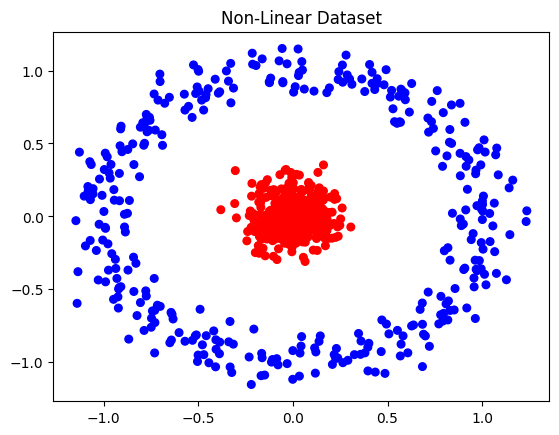

In [2]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=700, factor=0.1, noise=0.1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='bwr')
plt.title('Non-Linear Dataset')
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [4]:
# using linear kernel on non-linear dataset (just to test the accuracy)
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [5]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}%")

Accuracy: 0.4642857142857143%


In [28]:
zero_one_colourmap = ListedColormap(('blue', 'red'))

def plot_decision_boundary(X, y, clf):

    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start=X_set[:,0].min()-1,
                                  stop=X_set[:,0].max()+1,
                                  step=0.01),
                         np.arange(start=X_set[:,1].min()-1,
                                  stop=X_set[:,1].max()+1,
                                  step=0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                              X2.ravel()]).T).reshape(X1.shape),
                                              alpha=0.55, cmap=zero_one_colourmap)

    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set==j, 0], X_set[y_set==j, 1],
                   c=(zero_one_colourmap)(i), label=j)

    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    
    return plt.show()

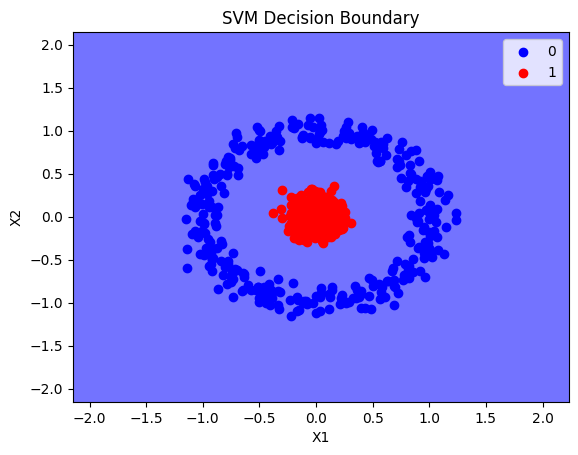

In [29]:
plot_decision_boundary(X, y, classifier)

In [30]:
def plot_3d(X, y):

    # calculating value of every X point on the z-axis - using RBF (Radial Basic Function).
    r = np.exp(-(X**2).sum(1)) # RBF Equation
    
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:,0], X[:,1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')

    return ax

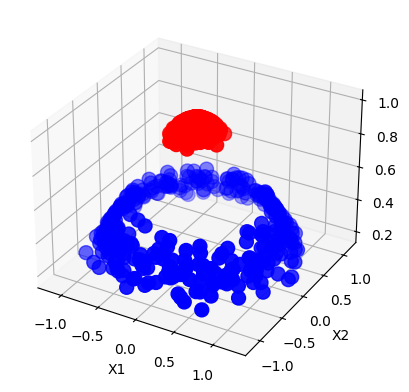

In [31]:
plot_3d(X, y)
plt.show()

### Using RBF Kernel

In [45]:
rbf_classifier = SVC(kernel='rbf')
rbf_classifier.fit(X_train, y_train)

SVC()

In [46]:
y_pred = rbf_classifier.predict(X_test)

In [47]:
accuracy = accuracy_score(y_test, y_pred)
print(f"RBF-Classifier Accuracy: {accuracy * 100}%")

RBF-Classifier Accuracy: 100.0%


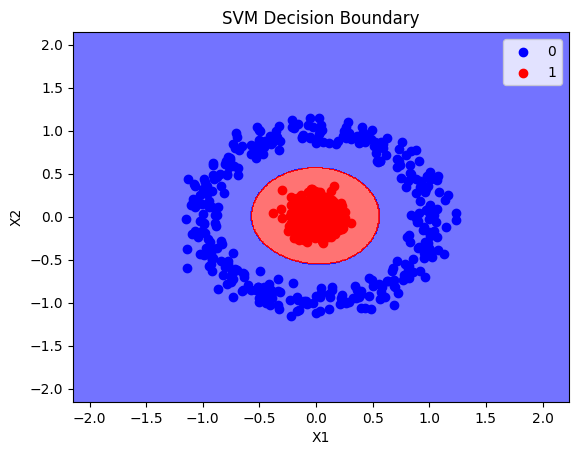

In [48]:
plot_decision_boundary(X, y, rbf_classifier)

### Using Polynomial Kernel

In [68]:
poly_classifier = SVC(kernel='poly', degree=4)
poly_classifier.fit(X_train, y_train)

SVC(degree=4, kernel='poly')

In [69]:
y_pred_poly = poly_classifier.predict(X_test)

In [84]:
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(accuracy_poly)

1.0


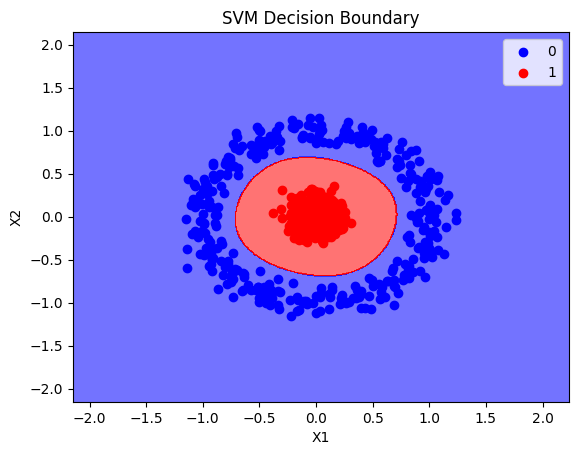

In [85]:
plot_decision_boundary(X, y, poly_classifier)

In [86]:
X

array([[-0.04606674, -0.01607927],
       [-0.80635967,  0.61183136],
       [ 0.07161853,  0.08514789],
       ...,
       [ 0.57089792,  0.87281754],
       [ 0.06814593, -0.02333016],
       [-0.16784192, -0.15738522]], shape=(700, 2))

In [87]:
np.exp(-(X**2)).sum(1) # Applying RBF on X

array([1.9976216 , 1.20967775, 1.98765997, 1.99007425, 1.99882181,
       1.99252685, 1.50799754, 1.99299857, 1.45719762, 1.22731492,
       1.99832169, 1.98640522, 1.41550988, 1.09709698, 1.38786774,
       1.98327002, 1.21252947, 1.28797828, 1.33606321, 1.99595437,
       1.31124169, 1.99685655, 1.41079859, 1.97987887, 1.99539632,
       1.94074376, 1.99938727, 1.98345558, 1.27106418, 1.98007038,
       1.97883255, 1.9847955 , 1.99283805, 1.98411313, 1.34083088,
       1.9971505 , 1.99197345, 1.25598557, 1.34569277, 1.36814085,
       1.99330424, 1.29623202, 1.13393073, 1.23969715, 1.96141248,
       1.19232509, 1.23001104, 1.9816101 , 1.42416175, 1.96404654,
       1.96743254, 1.11028849, 1.97968803, 1.23568664, 1.93646238,
       1.39342931, 1.93431805, 1.04607239, 1.21831155, 1.2843316 ,
       1.2250885 , 1.33357947, 1.97797052, 1.27948521, 1.9878902 ,
       1.35960152, 1.31621188, 1.99116093, 1.35946376, 1.31811355,
       1.41600824, 1.94065069, 1.93046313, 1.93352576, 1.43238

In [90]:
X_new = np.exp(-(X**2))

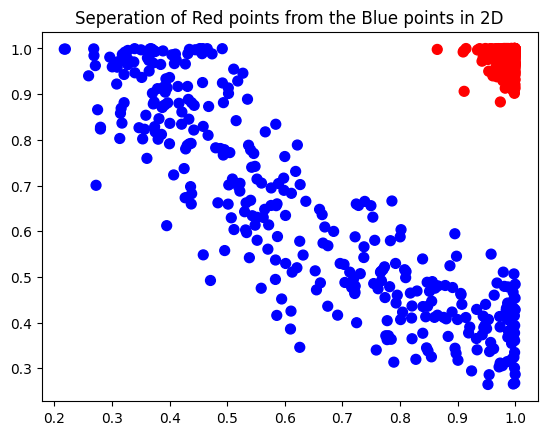

In [94]:
plt.scatter(X_new[:,0], X_new[:,1], c=y, s=50, cmap='bwr')
plt.title("Seperation of Red points from the Blue points in 2D")
plt.show()